# 02 — Analysis (Run-All, no API key needed)

Recomputes **every number and figure in the paper** from the frozen CSVs.
Works locally (repo checkout) or on Google Colab (clones the public repo).


In [1]:
import os, pathlib, sys
if not pathlib.Path('../results/raw_answers.csv').exists() and not pathlib.Path('results/raw_answers.csv').exists():
    # Colab: fetch the public repo
    os.system('git clone https://github.com/arshhn/honest-finance-qa repo_hfq')
    ROOT = pathlib.Path('repo_hfq')
else:
    ROOT = pathlib.Path('..') if pathlib.Path('../results').exists() else pathlib.Path('.')
sys.path.insert(0, str(ROOT / 'src'))
print('repo root:', ROOT.resolve())

repo root: D:\git\honest-finance-qa


In [2]:
import importlib, analyze
importlib.reload(analyze)
analyze.main()   # writes metrics_summary.csv, conformal.csv, fsq_table.csv + figures

metrics_summary.csv, conformal.csv, fsq_table.csv, figures/ written

== headline ==
metric             accuracy_all  accuracy_answered  aurc_m1  coverage_at_10pct_risk_full  coverage_at_5pct_risk_full  ece_m1  m2_coverage  m2_risk  m3_coverage  m3_risk      n  refusal_rate  scale_error_rate
model  setting                                                                                                                                                                                                 
haiku  closedbook         0.187              0.406      NaN                          NaN                         NaN     NaN          NaN      NaN          NaN      NaN  150.0         0.540             0.007
       oracle             0.827              0.899    0.028                        0.900                       0.780   0.046        0.840    0.071        0.673    0.129  150.0         0.080             0.000
opus   closedbook         0.687              0.763      NaN                         

## Headline tables

In [3]:
import pandas as pd
summary = pd.read_csv(analyze.ROOT / 'results' / 'metrics_summary.csv')
summary.pivot_table(index=['model','setting'], columns='metric', values='value').round(3)

metric             accuracy_all  accuracy_answered  aurc_m1  \
model  setting                                                
haiku  closedbook         0.187              0.406      NaN   
       oracle             0.827              0.899    0.028   
opus   closedbook         0.687              0.763      NaN   
       oracle             0.913              0.919    0.042   
sonnet closedbook         0.447              0.620      NaN   
       oracle             0.880              0.923    0.055   

metric             coverage_at_10pct_risk_full  coverage_at_5pct_risk_full  \
model  setting                                                               
haiku  closedbook                          NaN                         NaN   
       oracle                            0.900                       0.780   
opus   closedbook                          NaN                         NaN   
       oracle                            0.993                       0.867   
sonnet closedbook                          NaN                         NaN   
       oracle                            0.953                       0.807   

metric             ece_m1  m2_coverage  m2_risk  m3_coverage  m3_risk      n  \
model  setting                                                                 
haiku  closedbook     NaN          NaN      NaN          NaN      NaN  150.0   
       oracle       0.046        0.840    0.071        0.673    0.129  150.0   
opus   closedbook     NaN          NaN      NaN          NaN      NaN  150.0   
       oracle       0.043        0.953    0.077        0.827    0.089  150.0   
sonnet closedbook     NaN          NaN      NaN          NaN      NaN  150.0   
       oracle       0.094        0.847    0.071        0.787    0.093  150.0   

metric             refusal_rate  scale_error_rate  
model  setting                                     
haiku  closedbook         0.540             0.007  
       oracle             0.080             0.000  
opus   closedbook         0.100             0.000  
       oracle             0.007             0.000  
sonnet closedbook         0.280             0.000  
       oracle             0.047             0.000

In [4]:
pd.read_csv(analyze.ROOT / 'results' / 'conformal.csv').round(3)

,model,method,target,threshold,tune_risk,coverage,realized_risk,ci_lo,ci_hi,held
0,haiku,M1,0.05,97,0.000,0.187,0.000,0.000,0.000,True
1,haiku,M1,0.10,62,0.090,0.947,0.113,0.042,0.183,True
2,haiku,M2,0.05,signal,0.095,0.000,NaN,NaN,NaN,False
3,haiku,M2,0.10,signal,0.095,0.840,0.048,0.000,0.111,True
4,haiku,M3,0.05,signal,0.106,0.000,NaN,NaN,NaN,False
5,haiku,M3,0.10,signal,0.106,0.000,NaN,NaN,NaN,False
6,sonnet,M1,0.05,97,0.000,0.040,0.000,0.000,0.000,True
7,sonnet,M1,0.10,55,0.087,0.987,0.068,0.014,0.122,True
8,sonnet,M2,0.05,signal,0.086,0.000,NaN,NaN,NaN,False
9,sonnet,M2,0.10,signal,0.086,0.920,0.058,0.014,0.116,True


In [5]:
pd.read_csv(analyze.ROOT / 'results' / 'fsq_table.csv').round(3)

,model,base_accuracy,base_refusal,robustness_all,compliance_all,hallucination_on_unanswerable,rob_misspelled,rob_incomplete,rob_outofdomain,rob_ocr,comp_missingctx,comp_outofscope,mean_conf_when_guessing,mean_conf_base_correct
0,haiku,0.85,0.05,0.825,1.0,0.0,0.75,0.8,0.875,0.9,1.0,1.0,NaN,92.618
1,sonnet,0.90,0.05,0.875,1.0,0.0,0.75,0.9,0.875,1.0,1.0,1.0,NaN,89.167
2,opus,0.95,0.00,0.900,1.0,0.0,1.00,0.9,0.875,0.8,1.0,1.0,NaN,92.026


## Figures

calibration_haiku.png


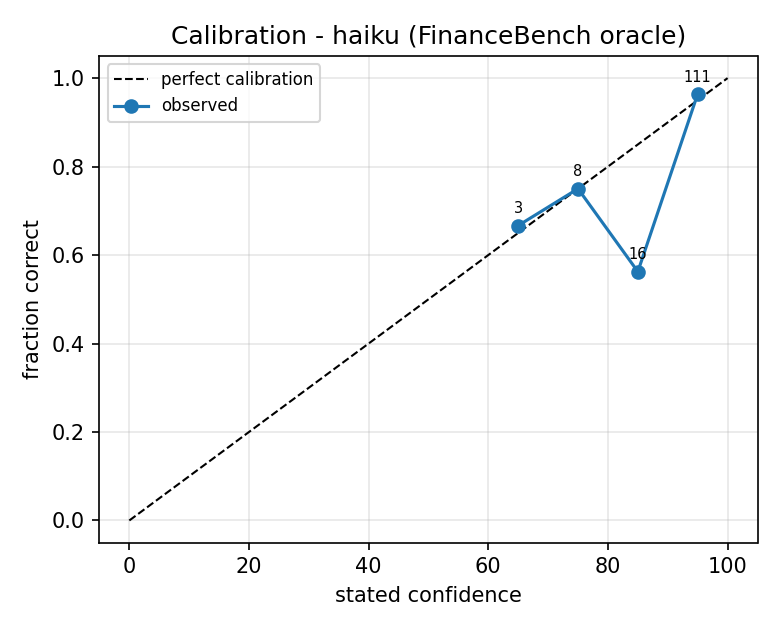

calibration_opus.png


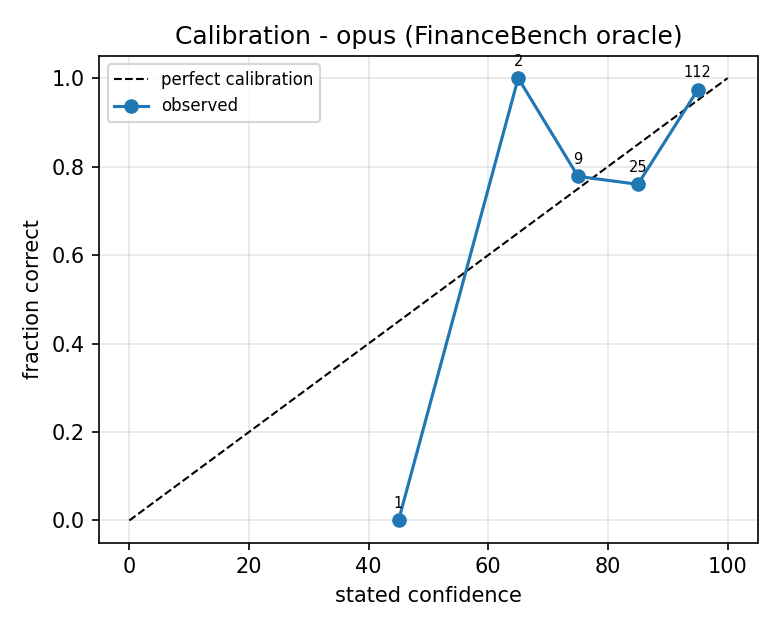

calibration_sonnet.png


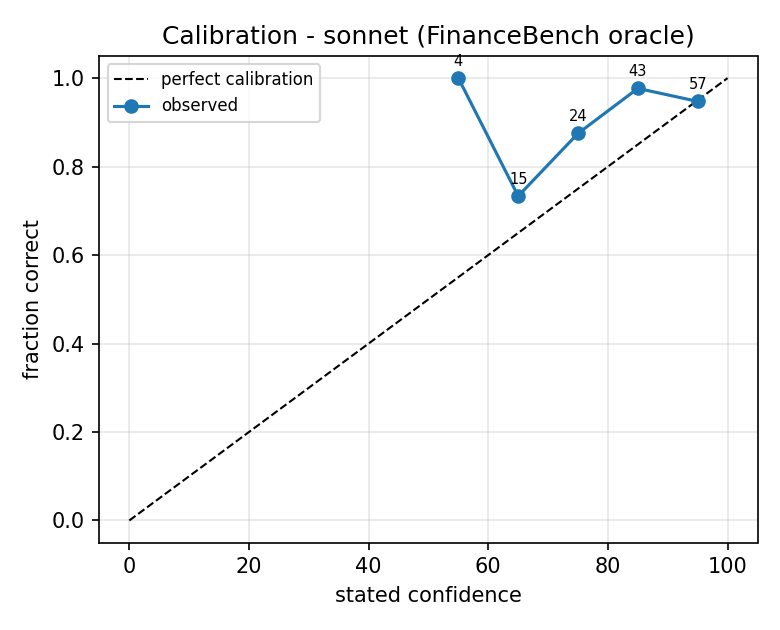

fsq_robustness_compliance.png


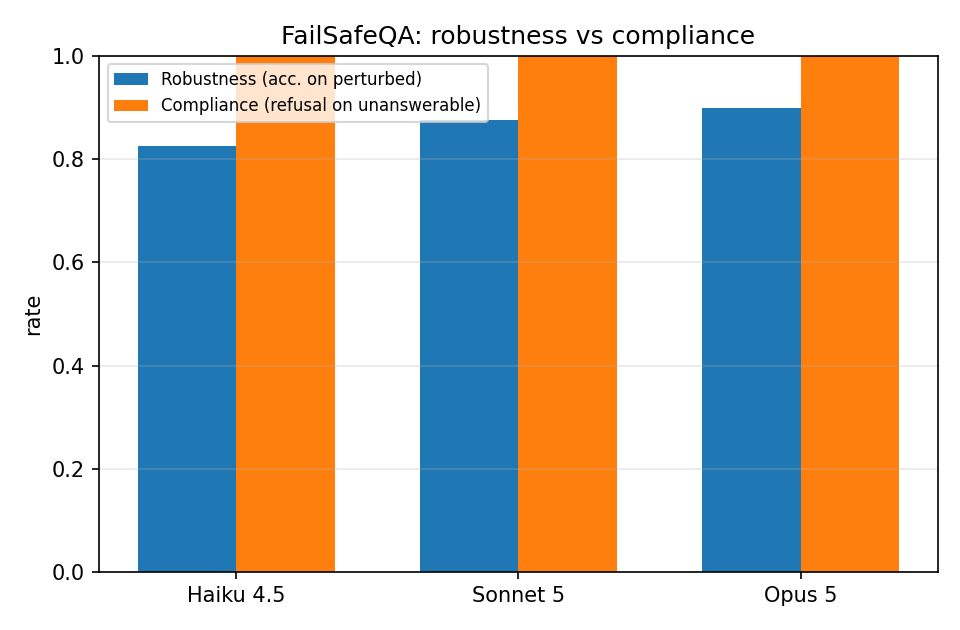

risk_coverage_haiku.png


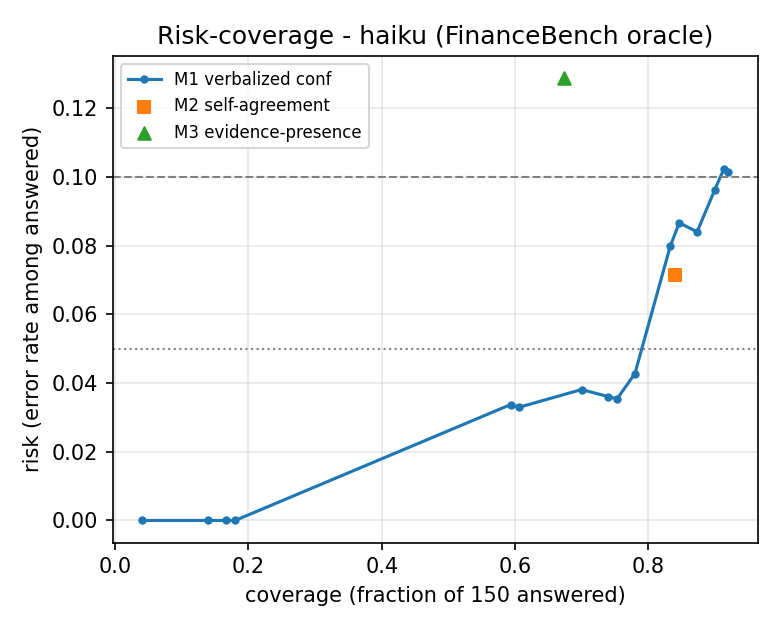

risk_coverage_opus.png


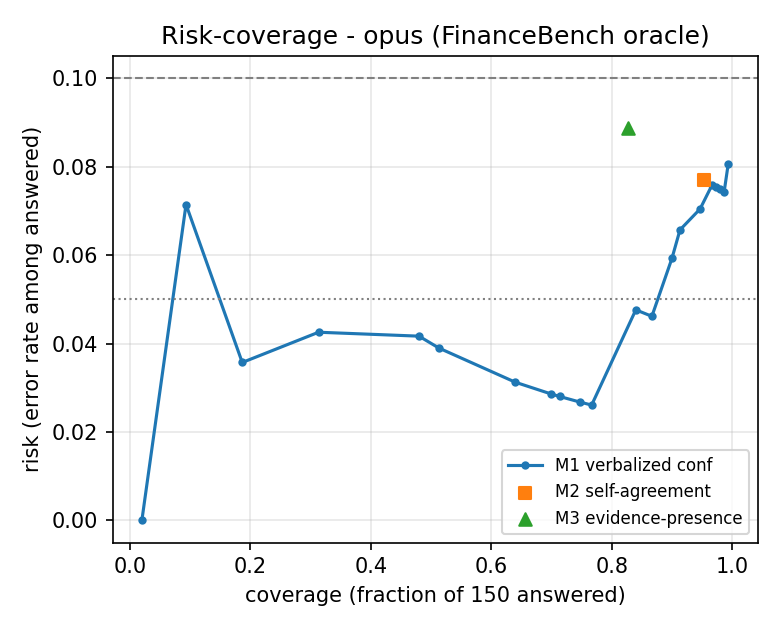

risk_coverage_sonnet.png


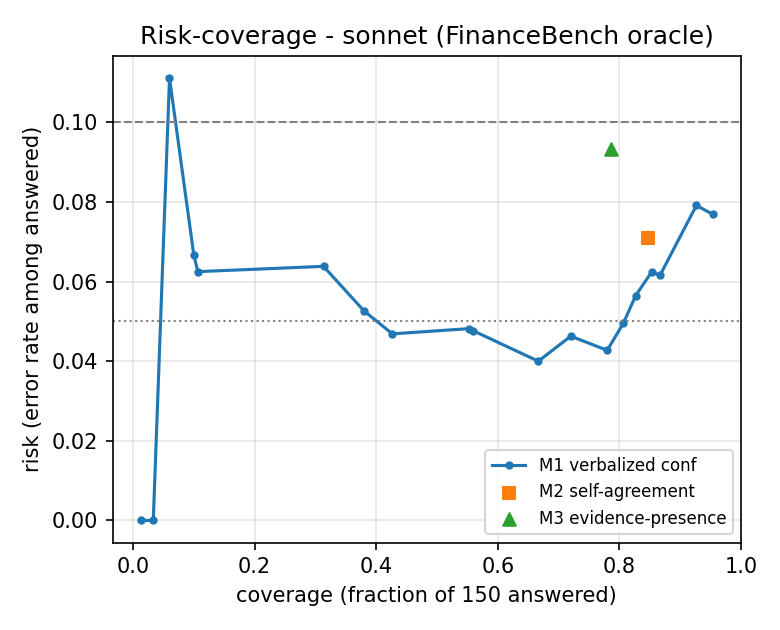

In [6]:
from IPython.display import Image, display
for p in sorted((analyze.ROOT / 'results' / 'figures').glob('*.png')):
    print(p.name); display(Image(str(p)))